In [1]:
from pathlib import Path
from dotenv import load_dotenv
import os

ROOT = Path.cwd().parent

env_path = ROOT / ".env.backtest"

load_dotenv(env_path)

print(env_path)
print(os.getenv("MONGO_HOST"))

os.chdir(Path.cwd().parent)

/Users/paulvogt/mongo_db_streamlit/.env.backtest
localhost


In [2]:
%pwd

'/Users/paulvogt/mongo_db_streamlit'

In [3]:
from infrastructure.mongo.mongo_repository import MongoRepository
from config.mongo_config import MongoCollection, MongoDatabase, MongoUser
from infrastructure.mongo.mongo_connection import MongoConnection

In [4]:
from bson import ObjectId
import pandas as pd

AGGR = [
  {
    "$sort": {
      'symbol': 1,
      "date": 1
    }
  },
  {
    "$group": {
      "_id": "$symbol",
      "firstDate": { "$first": "$date" },
      "lastDate": { "$last": "$date" }
    }
  },
  {
    "$project": {
      "_id": 0,
      "symbol": "$_id",
      "firstDate": 1,
      "lastDate": 1
    }
  }
]

with MongoConnection(user=MongoUser.APPUSER) as conn:
    constituents_repo = MongoRepository(
        conn,
        MongoDatabase.PROCESSED,
        MongoCollection.SCD_CONSTITUENTS
    )

    scd_df = pd.DataFrame(
        list(
            constituents_repo.find(
                projection={"symbol": 1, "fromDate": 1, "toDate": 1, "_id": 0}
            )
        )
    )
    cashflow_repo = MongoRepository(
        conn,
        MongoDatabase.RAW,
        MongoCollection.STAGED_CASHFLOW
    )
    income_repo = MongoRepository(
        conn,
        MongoDatabase.RAW,
        MongoCollection.STAGED_INCOMESTATEMENT
    )
    eod_repo = MongoRepository(
        conn,
        MongoDatabase.RAW,
        MongoCollection.STAGED_EODPRICE
    )
    df_cash = pd.DataFrame(list(cashflow_repo.execute_pipeline(AGGR)))
    df_income = pd.DataFrame(list(income_repo.execute_pipeline(AGGR)))
    df_eod = pd.DataFrame(list(eod_repo.execute_pipeline(AGGR)))

    company_data_repo = MongoRepository(
        conn,
        MongoDatabase.PROCESSED,
        MongoCollection.COMPANYDATA
    )
    docs = list(constituents_repo.execute_pipeline([{
          "$lookup": {
            "from": MongoCollection.COMPANYDATA.value,
            "localField": "symbol",
            "foreignField": "symbol",
            "as": "joinResult"
          }
        },
        {
          "$match": {
            "joinResult": { "$eq": [] }
          }
        },
        {
          "$project": {
            "joinResult": 0
          }
        }
      ]))
    df_company = pd.DataFrame(docs)
    
    



In [5]:
df_cash.sort_values(by=['symbol']).head()

,firstDate,lastDate,symbol
644,2000-01-31,2026-04-30,A
826,2015-03-31,2026-03-31,AA
742,1989-09-30,2026-03-31,AAL
821,2002-04-20,2026-04-25,AAP
466,1989-12-31,2026-03-28,AAPL


In [6]:
df_income.sort_values(by=['symbol']).head()

,firstDate,lastDate,symbol
209,1999-01-31,2026-04-30,A
425,2015-03-31,2026-03-31,AA
109,1985-09-30,2026-03-31,AAL
433,2001-03-31,2026-04-25,AAP
919,1985-09-30,2026-03-28,AAPL


In [7]:
df_eod.sort_values(by=['symbol']).head()

,firstDate,lastDate,symbol
1086,2007-01-03,2026-06-09,A
703,2007-01-03,2026-06-09,AA
996,2007-01-03,2026-06-09,AAL
767,2007-01-03,2026-06-09,AAP
117,2007-01-03,2026-06-09,AAPL


In [8]:
df_company.sort_values(by=['toDate']).tail(50)



,_id,companyName,symbol,fromDate,toDate
81,6a4f610c09e5dd9209c5ddf2,DirecTV,DTV,1900-01-01,2015-07-29 00:00:00
82,6a4f610c09e5dd9209c5ddf4,Hospira,HSP,1900-01-01,2015-09-02 00:00:00
83,6a4f610c09e5dd9209c5ddf6,Hudson City Bancorp,HCBK,1900-01-01,2015-11-02 00:00:00
84,6a4f610c09e5dd9209c5ddf8,Sigma-Aldrich,SIAL,1900-01-01,2015-11-19 00:00:00
85,6a4f610c09e5dd9209c5ddfa,Comcast K Corp,CMCSK,2015-09-18,2015-12-15 00:00:00
86,6a4f610c09e5dd9209c5ddfd,Chubb,ACE,1900-01-01,2016-01-19 00:00:00
87,6a4f610c09e5dd9209c5de00,Plum Creek Timber,PCL,1900-01-01,2016-02-22 00:00:00
88,6a4f610c09e5dd9209c5de03,Ensco,ESV,2012-07-31,2016-03-30 00:00:00
89,6a4f610c09e5dd9209c5de0a,Time Warner Cable,TWC,1900-01-01,2016-05-18 00:00:00
90,6a4f610c09e5dd9209c5de0c,Coca-Cola Enterprises,CCE,1900-01-01,2016-05-31 00:00:00


In [9]:
scd_df.head()

,symbol,fromDate,toDate
0,AYE,1900-01-01,1976-07-01 00:00:00
1,HNG,1900-01-01,1976-07-01 00:00:00
2,MCK,1900-01-01,1994-09-30 00:00:00
3,USL,1900-01-01,1997-06-17 00:00:00
4,SUN,1900-01-01,1998-12-11 00:00:00


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
### FUNKTION
def graphics(count_df : pd.DataFrame, titel : str = ""):
    # --- Grafik 1: Constituents pro Quartal ---
    plt.figure(figsize=(9, 5))

    plt.plot(
        count_df['date'],
        count_df['count'],
        linewidth=1.5,
        color='steelblue'
    )

    plt.axhline(500, color='red', linestyle='--', linewidth=1, label='Ziel: 500')
    plt.axhline(490, color='orange', linestyle=':', linewidth=1, label='±2% Band (490–510)')
    plt.axhline(510, color='orange', linestyle=':', linewidth=1)

    plt.fill_between(
        count_df['date'],
        490,
        510,
        alpha=0.1,
        color='orange'
    )

    plt.title(f"S&P 500 – {titel} pro Quartal", fontsize=13)
    plt.ylabel('Anzahl Constituents')
    plt.legend()
    plt.grid(True, alpha=0.3)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()


    # --- Grafik 2: Abweichung von 500 ---
    plt.figure(figsize=(9, 5))

    colors = [
        'red' if -d > 10 else 'steelblue'
        for d in count_df['deviation']
    ]

    plt.bar(
        count_df['date'],
        count_df['deviation'],
        width=80,
        color=colors,
        alpha=0.7
    )

    plt.axhline(0, color='black', linewidth=1)
    #plt.axhline(10, color='orange', linestyle='--', linewidth=1, label='±10 Grenze')
    plt.axhline(-10, color='orange', linestyle='-', linewidth=1, label='-10 Grenze')

    plt.title('Abweichung von 500', fontsize=13)
    plt.ylabel('Δ zu 500')
    plt.legend()
    plt.grid(True, alpha=0.3)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

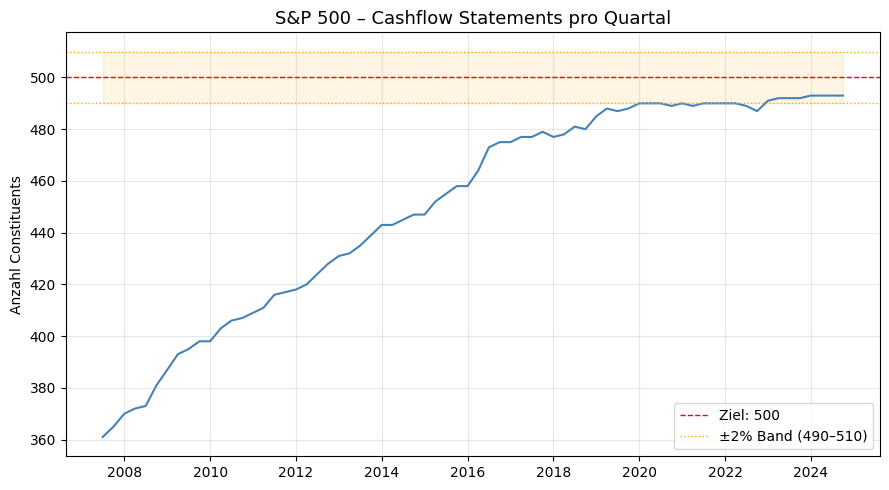

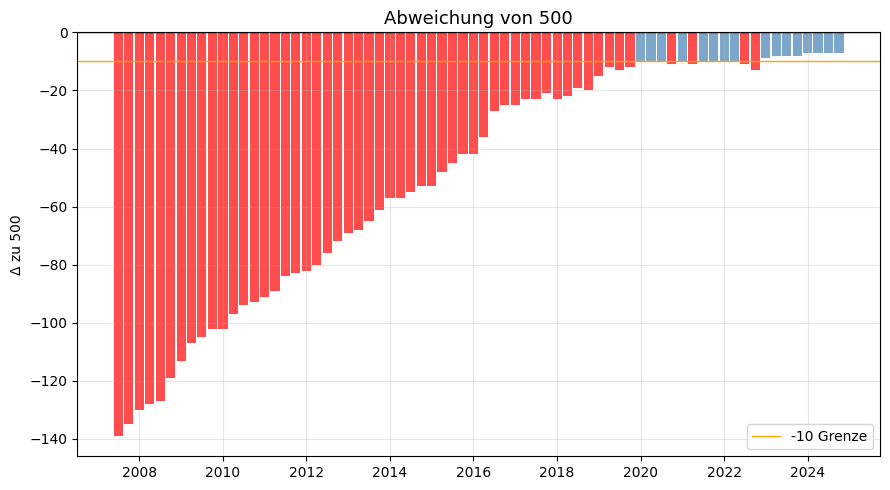

In [11]:
# Generate date range to check
date_range = pd.date_range(start='2007-07-01', end='2024-12-31', freq='QS')

df_enriched_cash = pd.merge(scd_df, df_cash, on="symbol")

# Count active constituents per date
counts = []
for date in date_range:
    active = ((df_enriched_cash['firstDate'] <= date) & (df_enriched_cash['lastDate'] >= date) & (df_enriched_cash['fromDate'] <= date) & (df_enriched_cash['toDate'] >= date)).sum()
    counts.append({'date': date, 'count': active})

count_df = pd.DataFrame(counts)
count_df['deviation'] = count_df['count'] - 500

graphics(count_df, "Cashflow Statements")

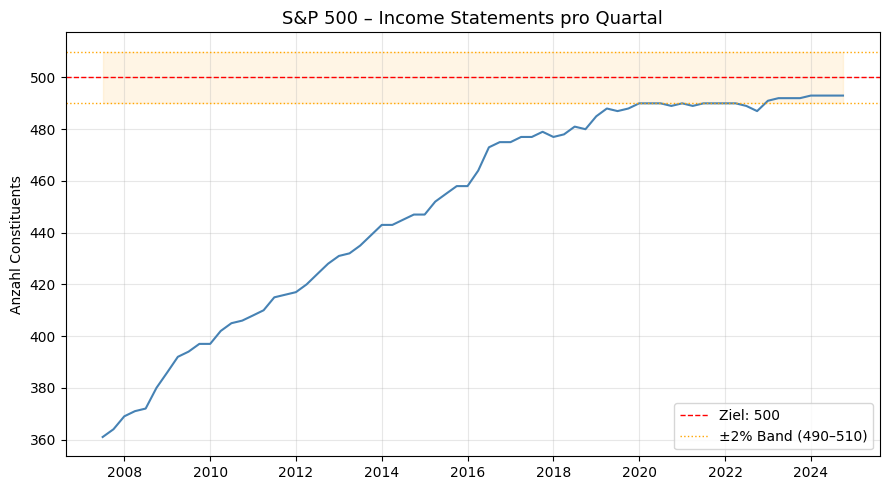

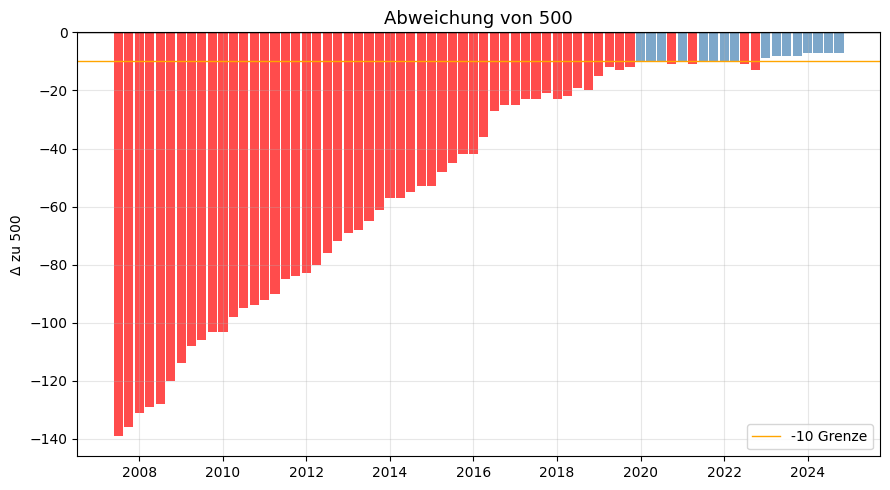

In [12]:
# Generate date range to check
date_range = pd.date_range(start='2007-07-01', end='2024-12-31', freq='QS')

df_enriched = pd.merge(scd_df, df_income, on="symbol")

# Count active constituents per date
counts = []
for date in date_range:
    active = ((df_enriched['firstDate'] <= date) & (df_enriched['lastDate'] >= date) & (df_enriched['fromDate'] <= date) & (df_enriched['toDate'] >= date)).sum()
    counts.append({'date': date, 'count': active})

count_df = pd.DataFrame(counts)
count_df['deviation'] = count_df['count'] - 500

graphics(count_df, "Income Statements")

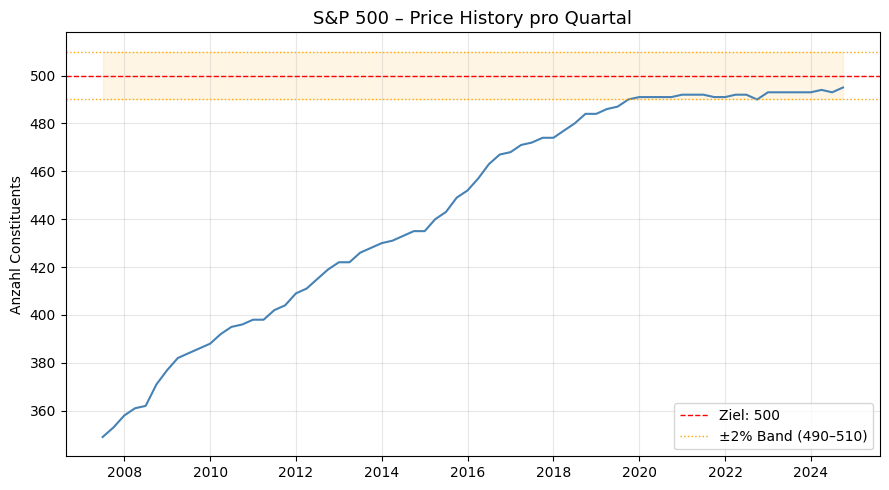

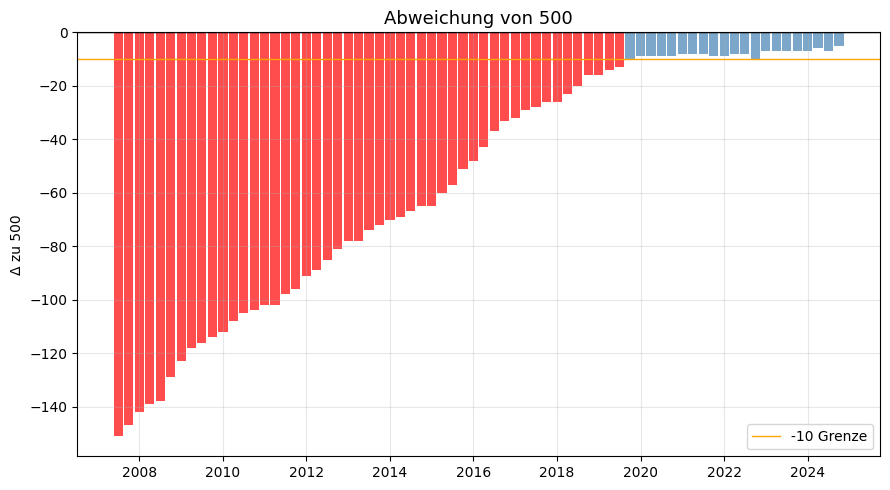

In [13]:
# Generate date range to check
date_range = pd.date_range(start='2007-07-01', end='2024-12-31', freq='QS')

df_enriched = pd.merge(scd_df, df_eod, on="symbol")

# Count active constituents per date
counts = []
for date in date_range:
    active = ((df_enriched['firstDate'] <= date) & (df_enriched['lastDate'] >= date) & (df_enriched['fromDate'] <= date) & (df_enriched['toDate'] >= date)).sum()
    counts.append({'date': date, 'count': active})

count_df = pd.DataFrame(counts)
count_df['deviation'] = count_df['count'] - 500

graphics(count_df, "Price History")

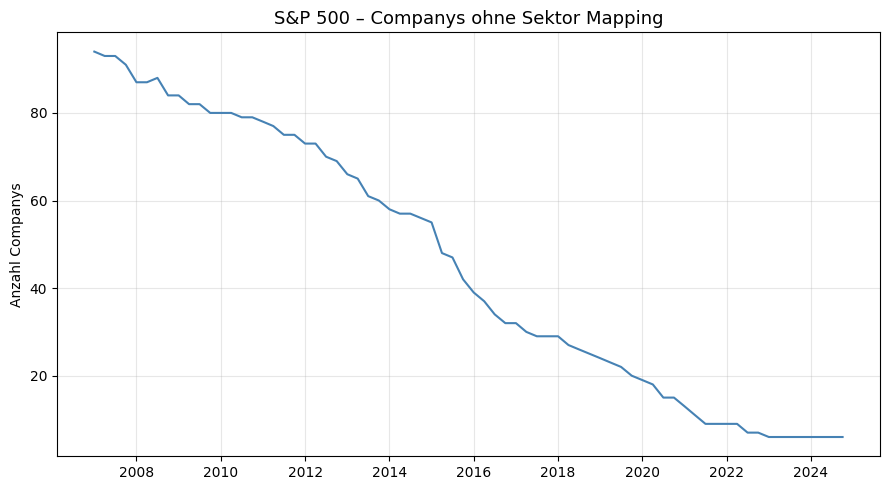

In [14]:
# Generate date range to check
date_range = pd.date_range(start='2007-01-01', end='2024-12-31', freq='QS')

# Count active constituents per date
counts = []
for date in date_range:
    no_sector_mapping = ((df_company['fromDate'] <= date) & (df_company['toDate'] >= date)).sum()
    counts.append({'date': date, 'count': no_sector_mapping})

count_df = pd.DataFrame(counts)

# --- Grafik: Active Constituents over time ---
plt.figure(figsize=(9, 5))

plt.plot(
    count_df['date'],
    count_df['count'],
    linewidth=1.5,
    color='steelblue'
)

plt.title("S&P 500 – Companys ohne Sektor Mapping", fontsize=13)
plt.ylabel('Anzahl Companys')

plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [15]:
df_cash = df_cash.add_suffix("_cash").rename(columns={"symbol_cash": "symbol"})
df_income = df_income.add_suffix("_income").rename(columns={"symbol_income": "symbol"})
df_eod = df_eod.add_suffix("_eod").rename(columns={"symbol_eod": "symbol"})
df_scd = scd_df.add_suffix("_scd").rename(columns={"symbol_scd": "symbol"})

df_merged = df_cash.merge(df_income, on="symbol", how="inner") \
                   .merge(df_eod, on="symbol", how="inner") \
                   .merge(df_scd, on="symbol", how="inner")

df_merged.describe()

,firstDate_cash,lastDate_cash,firstDate_income,lastDate_income,firstDate_eod,lastDate_eod,fromDate_scd
count,755,755,755,755,755,755,755
mean,1998-04-09 02:26:51.655629184,2025-07-22 07:54:54.834437376,1996-03-16 15:53:38.543046400,2025-07-23 12:46:43.708609536,2009-01-09 19:57:46.490066176,2025-09-30 12:35:17.086092544,1982-02-04 15:07:52.052980160
min,1987-03-31 00:00:00,2014-03-30 00:00:00,1985-08-31 00:00:00,2014-03-30 00:00:00,2007-01-03 00:00:00,2016-01-29 00:00:00,1900-01-01 00:00:00
25%,1989-12-31 00:00:00,2026-03-31 00:00:00,1985-09-30 00:00:00,2026-03-31 00:00:00,2007-01-03 00:00:00,2026-06-09 00:00:00,1957-03-04 00:00:00
50%,1994-03-31 00:00:00,2026-03-31 00:00:00,1993-03-31 00:00:00,2026-03-31 00:00:00,2007-01-03 00:00:00,2026-06-09 00:00:00,2005-10-03 00:00:00
75%,2004-03-31 00:00:00,2026-03-31 00:00:00,2004-03-31 00:00:00,2026-03-31 00:00:00,2007-01-03 00:00:00,2026-06-09 00:00:00,2016-09-15 12:00:00
max,2025-12-31 00:00:00,2026-05-31 00:00:00,2025-12-31 00:00:00,2026-05-31 00:00:00,2026-02-10 00:00:00,2026-06-09 00:00:00,2026-05-07 00:00:00


In [16]:
df_merged["fromDate"] = df_merged[
    ["firstDate_cash", "firstDate_income", "firstDate_eod", "fromDate_scd"]
].max(axis=1)

df_merged["toDate"] = df_merged[
    ["lastDate_cash", "lastDate_income", "lastDate_eod", "toDate_scd"]
].min(axis=1)

df_merged = df_merged.drop(["lastDate_cash", "lastDate_income", "lastDate_eod", "toDate_scd"], axis=1)
df_merged =df_merged.drop(["firstDate_cash", "firstDate_income", "firstDate_eod", "fromDate_scd"], axis=1)

In [17]:
df_merged.describe()

,fromDate
count,755
mean,2012-07-28 16:05:05.165562880
min,2007-01-03 00:00:00
25%,2007-01-03 00:00:00
50%,2009-01-30 00:00:00
75%,2017-09-30 12:00:00
max,2026-05-07 00:00:00


In [18]:
df_merged_wo_non_mappable = df_merged[
    ~df_merged["symbol"].isin(df_company["symbol"])
]

df_merged_wo_non_mappable.describe()

,fromDate
count,733
mean,2012-08-16 07:02:22.428376320
min,2007-01-03 00:00:00
25%,2007-01-03 00:00:00
50%,2009-03-04 00:00:00
75%,2017-11-01 00:00:00
max,2026-05-07 00:00:00


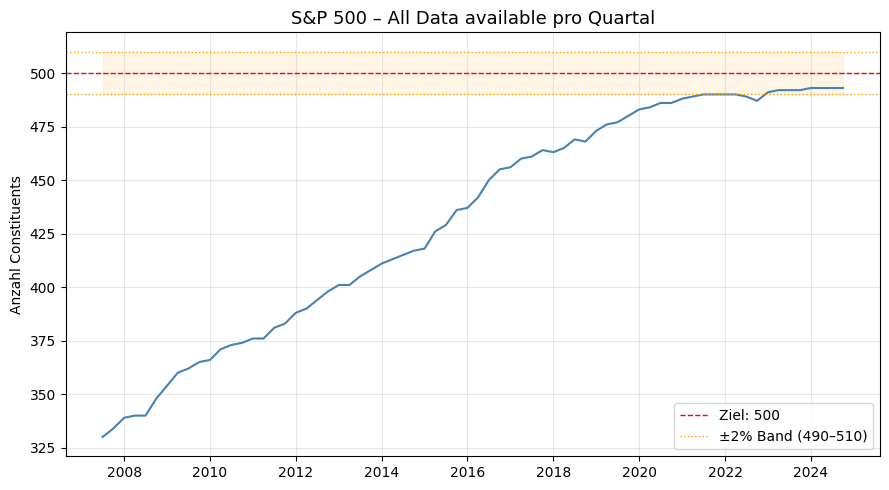

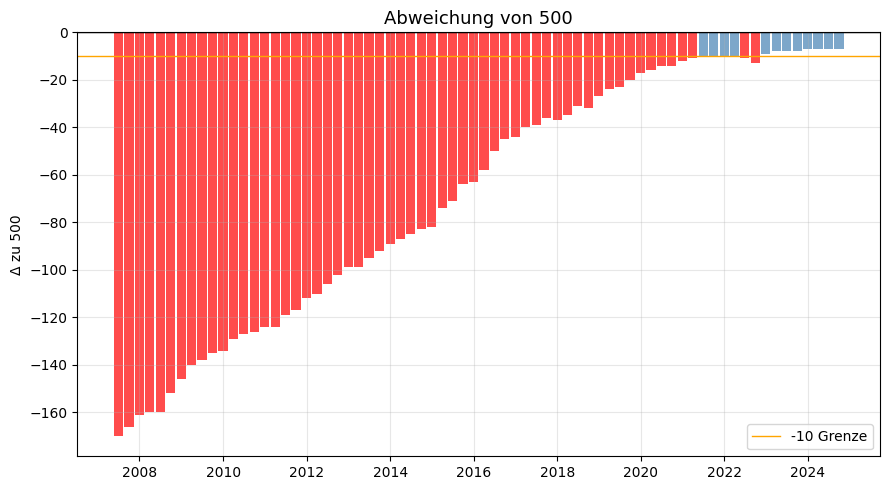

In [19]:
date_range = pd.date_range(start='2007-07-01', end='2024-12-31', freq='QS')

# Count active constituents per date
counts = []
for date in date_range:
    active = ((df_merged_wo_non_mappable['fromDate'] <= date) & (df_merged_wo_non_mappable['toDate'] >= date)).sum()
    counts.append({'date': date, 'count': active})

count_df = pd.DataFrame(counts)
count_df['deviation'] = count_df['count'] - 500

graphics(count_df, "All Data available")